In [1]:
import ast
from matplotlib import pyplot as plt
import pandas as pd
df = pd.read_csv(r'C:\Users\GEORGE TECHNOLOGY EN\Documents\data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


In [2]:
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [3]:
df = df[df['job_title_short'] == 'Data Analyst']

In [4]:
df_expoled = df.explode('job_skills')

In [6]:
skill_stats = df_expoled.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg', 'median')
)

In [14]:
skill_stats = skill_stats.sort_values(by='skill_count',ascending=False).head(10)

In [15]:
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


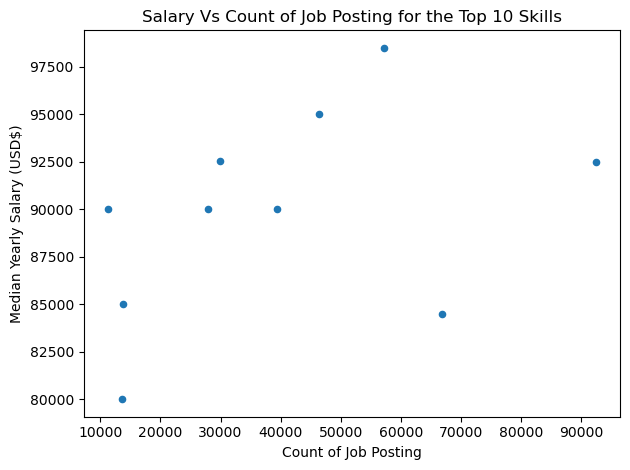

In [18]:
skill_stats.plot(kind='scatter',x= 'skill_count',y='median_salary')
plt.title('Salary Vs Count of Job Posting for the Top 10 Skills')
plt.ylabel('Median Yearly Salary (USD$)')
plt.xlabel('Count of Job Posting')
plt.tight_layout()
plt.show()

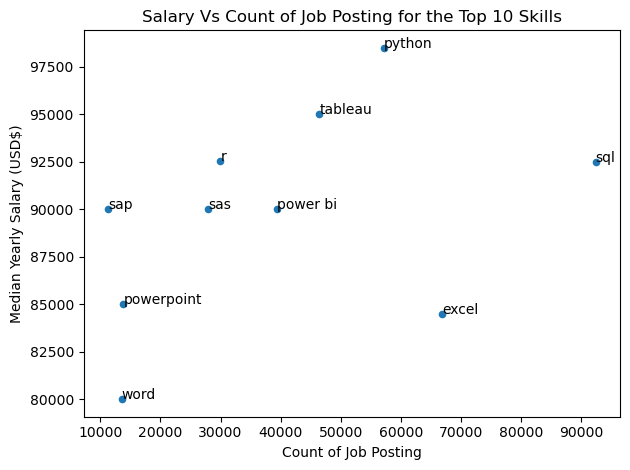

In [21]:
# inorder to act the the text like (sql, python) in your plot you use the text method 
skill_stats.plot(kind='scatter',x= 'skill_count',y='median_salary')
plt.title('Salary Vs Count of Job Posting for the Top 10 Skills')
plt.ylabel('Median Yearly Salary (USD$)')
plt.xlabel('Count of Job Posting')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
 
plt.show()